## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga datos y representa la serie

In [2]:
df = pd.read_csv('data/AirPassengers.csv', index_col='date', parse_dates=True)
df.head(144)

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

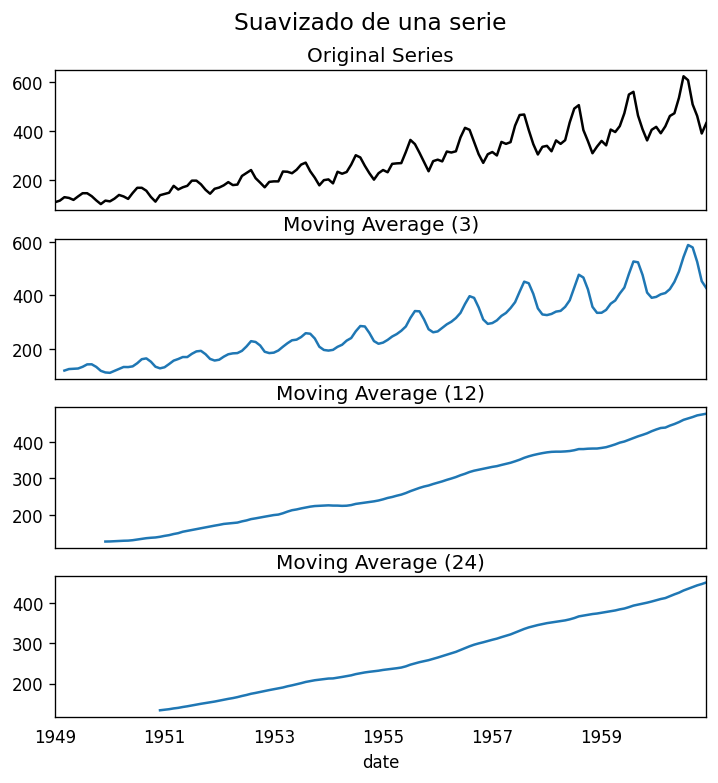

In [4]:
plt.rcParams.update({'xtick.bottom' : False, 'axes.titlepad':5})

# Media móviles
df_ma = df.value.rolling(3).mean()
df_ma_12 = df.value.rolling(12).mean()
df_ma_24 = df.value.rolling(24).mean()

# Plot
fig, axes = plt.subplots(4,1, figsize=(7, 7), sharex=True, dpi=120)
df['value'].plot(ax=axes[0], color='k', title='Original Series')
df_ma.plot(ax=axes[1], title='Moving Average (3)')
df_ma_12.plot(ax=axes[2], title='Moving Average (12)')
df_ma_24.plot(ax=axes[3], title='Moving Average (24)')
fig.suptitle('Suavizado de una serie', y=0.95, fontsize=14)
plt.show()

## 3. Comprueba de manera estadística si la serie es o no estacionaria.

In [5]:
from statsmodels.tsa.stattools import adfuller

serie = df['value']

# --- Prueba 1: Augmented Dickey-Fuller (ADF) ---
# H0: la serie tiene raíz unitaria (no es estacionaria)
# Si p-value > 0.05 → no podemos rechazar H0 → la serie NO es estacionaria
adf_result = adfuller(serie)
print('=== ADF Test ===')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print(f'Valores críticos: {adf_result[4]}')
if adf_result[1] > 0.05:
    print('→ p-value > 0.05: NO rechazamos H0. La serie NO es estacionaria.\n')
else:
    print('→ p-value <= 0.05: Rechazamos H0. La serie ES estacionaria.\n')

=== ADF Test ===
ADF Statistic : 0.8154
p-value       : 0.9919
Valores críticos: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
→ p-value > 0.05: NO rechazamos H0. La serie NO es estacionaria.



## 4. Aplica una transformación logarítmica

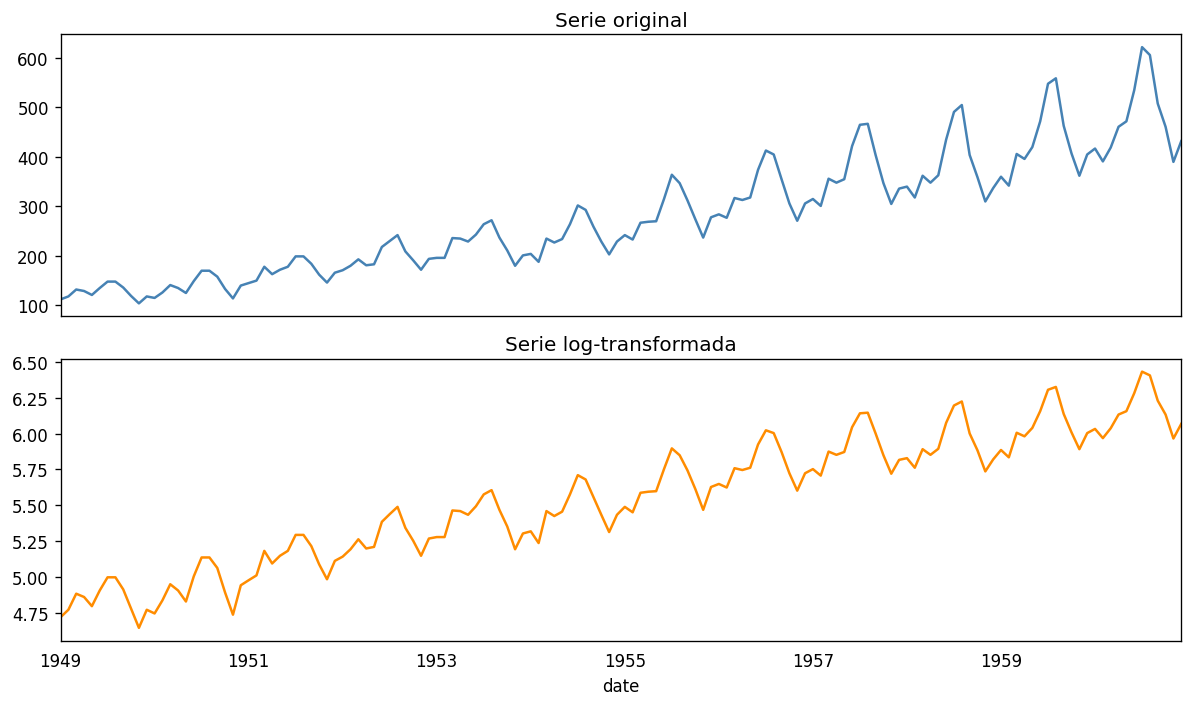

date
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
Name: log_value, dtype: float64

In [6]:
# Transformación logarítmica
# Guardamos la serie transformada para usarla en el modelado y, más adelante, invertirla con exp().
df['log_value'] = np.log(df['value'])

# Visualización comparativa
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True, dpi=120)
df['value'].plot(ax=ax[0], title='Serie original', color='steelblue')
df['log_value'].plot(ax=ax[1], title='Serie log-transformada', color='darkorange')
fig.tight_layout()
plt.show()

# Comprobamos la nueva serie y la guardamos en una variable para uso posterior.
log_serie = df['log_value']
log_serie.head()

## 5. Divide en train y test. Guarda 20 muestras para test.

In [7]:
# Asegúrate de ejecutar esto en tu celda del Paso 5
t = 20 # 20 muestras para test

# Usamos la serie con transformación logarítmica
train_log = df['log_value'][:-t]
test_log = df['log_value'][-t:]

# Guardamos el test original para poder calcular el error real después
test_orig = df['value'][-t:]

print(f"Train shape: {train_log.shape}, Test shape: {test_log.shape}")

Train shape: (124,), Test shape: (20,)


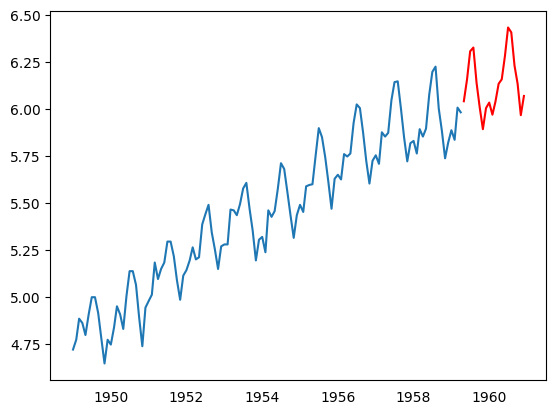

In [9]:
import matplotlib.pyplot as plt

plt.plot(df.index[:-t], train_log)
plt.plot(df.index[-t:], test_log, color='r');

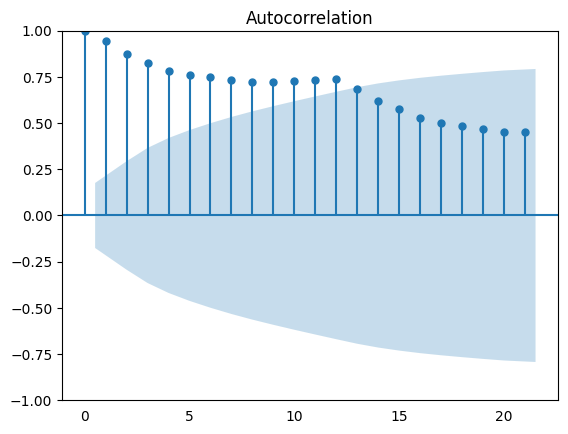

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(train_log);

In [12]:
from statsmodels.tsa.ar_model import AutoReg

# AR(1)
mod = AutoReg(train_log, 1)
res = mod.fit()
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:              log_value   No. Observations:                  124
Model:                     AutoReg(1)   Log Likelihood                 104.230
Method:               Conditional MLE   S.D. of innovations              0.104
Date:                Mon, 11 May 2026   AIC                           -202.461
Time:                        10:21:57   BIC                           -194.024
Sample:                    02-01-1949   HQIC                          -199.034
                         - 04-01-1959                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2403      0.130      1.849      0.064      -0.014       0.495
log_value.L1     0.9577      0.024     40.201      0.000       0.911       1.004
                                    Roots   

c:\Users\rns_2\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 6. Crea tu primer modelo ARIMA

In [14]:
from pmdarima.arima import auto_arima
from pmdarima.arima import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

#1. sin seasonality
model = auto_arima(train_log,
                   start_p = 1,
                   start_q = 1,
                   max_p = 5,
                   max_q = 5,
                   max_d = 3,
                   trace=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-208.997, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-201.351, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-202.849, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-204.251, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-202.180, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-204.379, Time=0.04 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-225.739, Time=0.17 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-229.588, Time=0.23 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-229.000, Time=0.20 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-233.691, Time=0.25 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-214.822, Time=0.12 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=-232.7

In [15]:
model.fit(train_log)
predictions1 = model.predict(20)

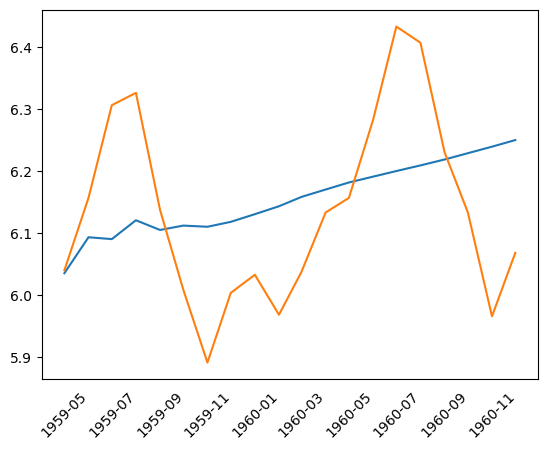

In [16]:
plt.plot(predictions1)
plt.plot(test_log)
plt.xticks(rotation=45);

In [17]:
#2 sin auto-arima
import itertools
p= range(4,13)
d=q=range(0,5)
pdq = list(itertools.product(p,d,q))
pdq[:10]
results = []
for param in pdq:
    try:
        model_arima = ARIMA(order=param)
        model_arima_fit = model_arima.fit(train_log)
        results.append((param,model_arima_fit.aic()))
    except:
        continue
resultados_df = pd.DataFrame(results, columns=['ARIMA params', 'AIC']).sort_values('AIC')
resultados_df.head()

,ARIMA params,AIC
206,"(12, 1, 1)",-390.082667
208,"(12, 1, 3)",-388.988416
205,"(12, 1, 0)",-388.983853
207,"(12, 1, 2)",-387.114847
184,"(11, 1, 4)",-383.766467


In [18]:
from sklearn.metrics import mean_squared_error

In [19]:
#3 con seasonality
model = auto_arima(train_log,
                    start_p=1,
                    start_q=1,
                    max_d=3,
                    max_p=5,
                    max_q=5,
                    m = 12,
                    trace=True,
                    stepwise=True)

print(model.aic())

predictions = model.predict(20)
print("mean_squared_error:", mean_squared_error(test_log, predictions))

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=-409.584, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-290.649, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-399.417, Time=0.66 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-353.179, Time=0.26 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-125.472, Time=0.01 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=-411.631, Time=0.64 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-384.170, Time=0.11 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=-409.714, Time=1.70 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=-405.268, Time=0.60 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=-408.108, Time=1.32 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=-408.087, Time=0.36 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=-410.728, Time=0.74 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-409.956, Time=1.27 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=-300.825, Time=0.14 sec
 ARIMA(0,0,2)(0,1,1

## 7. Representa en una gráfica los datos de test y tus predicciones.

SARIMA - MAE: 17.41 pasajeros
SARIMA - RMSE: 19.44 pasajeros


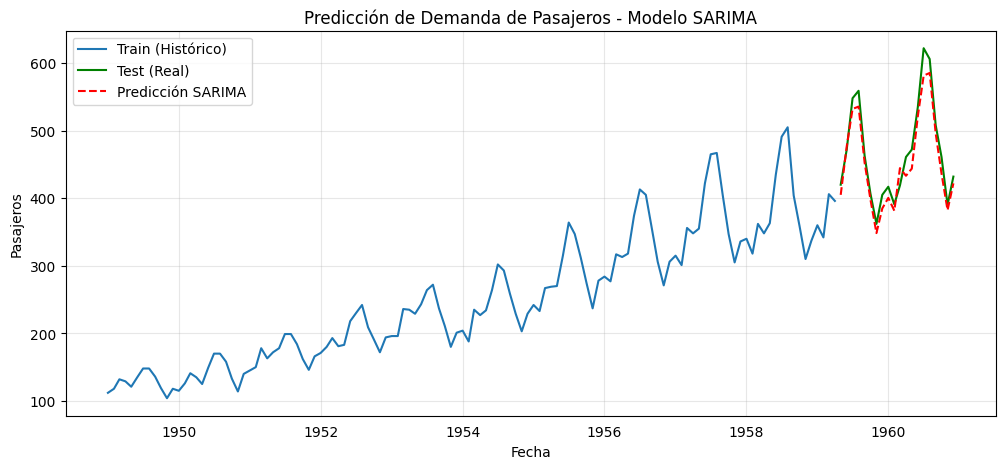

In [ ]:
# 1. Hacer la predicción sobre los 20 meses de test
pred_log = best_model.forecast(steps=t)

# 2. Invertir la transformación logarítmica
pred_orig = np.exp(pred_log)

# 3. Calcular métricas
mae_arima = mean_absolute_error(test_orig, pred_orig)
rmse_arima = np.sqrt(mean_squared_error(test_orig, pred_orig))
print(f"SARIMA - MAE: {mae_arima:.2f} pasajeros")
print(f"SARIMA - RMSE: {rmse_arima:.2f} pasajeros")

# 4. Gráfica
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(df.index[:-t], df['value'][:-t], label='Train (Histórico)')
plt.plot(df.index[-t:], test_orig, label='Test (Real)', color='green')
plt.plot(df.index[-t:], pred_orig, label='Predicción SARIMA', color='red', linestyle='--')

plt.title('Predicción de Demanda de Pasajeros - Modelo SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

Decision Tree - MAE: 43.30, RMSE: 53.85
Random Forest - MAE: 38.56, RMSE: 55.80


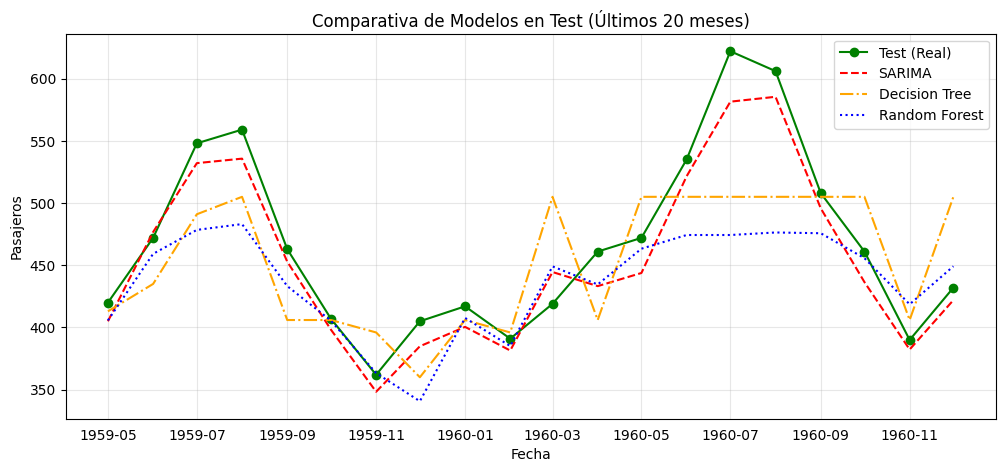

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Preparar los datos (Feature Engineering con lags)
# Usaremos 12 lags (1 año de retardo) para capturar la estacionalidad
df_ml = pd.DataFrame({'target': df['log_value']})

for i in range(1, 13):
    df_ml[f'lag_{i}'] = df_ml['target'].shift(i)

# Eliminar los primeros 12 registros que ahora tienen NaNs por los retardos
df_ml.dropna(inplace=True)

# 2. Separar en X (features) e y (target)
X = df_ml.drop('target', axis=1)
y = df_ml['target']

# 3. Train/Test split (últimos 20 para test)
X_train, X_test = X[:-t], X[-t:]
y_train, y_test = y[:-t], y[-t:]

# 4. Entrenar y predecir con Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred_log = dt_model.predict(X_test)
dt_pred = np.exp(dt_pred_log) # Invertir logaritmo

# 5. Entrenar y predecir con Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred_log = rf_model.predict(X_test)
rf_pred = np.exp(rf_pred_log) # Invertir logaritmo

# 6. Calcular Métricas
print(f"Decision Tree - MAE: {mean_absolute_error(test_orig, dt_pred):.2f}, RMSE: {np.sqrt(mean_squared_error(test_orig, dt_pred)):.2f}")
print(f"Random Forest - MAE: {mean_absolute_error(test_orig, rf_pred):.2f}, RMSE: {np.sqrt(mean_squared_error(test_orig, rf_pred)):.2f}")

# 7. Gráfica comparativa
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(df.index[-t:], test_orig, label='Test (Real)', color='green', marker='o')
plt.plot(df.index[-t:], pred_orig, label='SARIMA', color='red', linestyle='--')
plt.plot(df.index[-t:], dt_pred, label='Decision Tree', color='orange', linestyle='-.')
plt.plot(df.index[-t:], rf_pred, label='Random Forest', color='blue', linestyle=':')

plt.title('Comparativa de Modelos en Test (Últimos 20 meses)')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()